# 11 — ФИНАЛЬНЫЙ прогон: все улучшения вместе (2024–2026)

Собираем всё, что нашли за исследование:
- полная вселенная 173, все монеты одновременно, 2024-01 → 2026;
- сигнал −7%/15m, first-trigger (lookahead-free);
- **price-step fill** (iter10) — Δ=2%, рамп, ≤10 траншей;
- **классификатор-фильтр** (iter06), но честно — **walk-forward** (expanding-window,
  предсказания ВНЕ обучения; pred>0 = торгуем);
- **tail-лимиты** (iter09): catastrophe-стоп −20% + kill-switch K=40 (дефолт-он);
- **реинвестиция** (iter07, compound size = 2% капитала/сделку).

Внизу: таблица прогрессии улучшений + детальная статистика финала.

In [1]:
import sys; sys.path.insert(0,".")
from _lab import *
import numpy as np, pandas as pd
from pathlib import Path
import heapq
from sklearn.ensemble import HistGradientBoostingRegressor
WIN=15;H=240;COOLDOWN=10;N_MAX=10;FEE=0.00075;THR=0.07;DELTA=0.02;DAY=1440

def clusters(c,thr):
    if len(c)<WIN+5: return []
    r=np.full(len(c),np.nan); r[WIN:]=c[WIN:]/c[:-WIN]-1
    cond=r<=-thr; out=[]; i=WIN; n=len(c)
    while i<n:
        if not cond[i] or (i>0 and cond[i-1]): i+=1; continue
        start=i;last_true=i;falses=0;j=i+1
        while j<n:
            if cond[j]: last_true=j;falses=0
            else:
                falses+=1
                if falses>=COOLDOWN: break
            j+=1
        out.append((start,last_true)); i=last_true+COOLDOWN+1
    return out
def fills_price(c,st,en):
    pos=[st]; lastc=c[st]; t=st+1
    while t<=en and len(pos)<N_MAX:
        if c[t]<=lastc*(1-DELTA): pos.append(t); lastc=c[t]
        t+=1
    return pos
def fills_time(c,st,en):
    pos=[st]; last=st; t=st+1
    while t<=en and len(pos)<N_MAX:
        if t-last>=3: pos.append(t); last=t
        t+=1
    return pos
def avg_entry(c,pos,n):
    pos=[p for p in pos if p+1<n]
    pr=np.array([c[p+1] for p in pos]); ws=np.arange(1,len(pr)+1,dtype=float); ws/=ws.sum()
    return (ws*pr).sum()
def feats(c,v,h,l,st):
    def ret(k): return c[st]/c[st-k]-1 if st-k>=0 else np.nan
    base=np.median(v[max(0,st-DAY):st]) if st>60 else np.nan
    lr=np.diff(np.log(c[max(0,st-60):st+1]))
    return [ret(1),ret(3),ret(5),ret(15),ret(30),ret(60),
            (c[st]/c[st-5]-1)-(c[st-5]/c[st-15]-1 if st-15>=0 else np.nan),
            v[st-14:st+1].sum()/(base*15) if base and base>0 else np.nan,
            v[st]/base if base and base>0 else np.nan,
            lr.std() if len(lr)>5 else np.nan,
            (h[st-14:st+1].max()-l[st-14:st+1].min())/c[st],
            c[st]/h[max(0,st-DAY):st+1].max()-1, c[st]/l[max(0,st-DAY):st+1].min()-1,
            0]  # dstreak placeholder, filled in main pass
FEATN=["r1","r3","r5","r15","r30","r60","accel","surge15","surge1","volreg","rng15","hi_d","lo_d","dstreak"]

In [2]:
# full-universe pass: features + price-step & time pnl + stop path + breadth
rows=[]
for s in list_symbols():
    try: df=ohlcv(s,"2024-01-01","2026-07-01","1min")
    except Exception: continue
    c=df["close"].to_numpy("float64");v=df["volume"].to_numpy("float64")
    h=df["high"].to_numpy("float64");l=df["low"].to_numpy("float64");ts=df.index;n=len(c)
    for (st,en) in clusters(c,THR):
        ex=en+1+H
        if st<DAY or st+1>=n or ex>=n: continue
        aP=avg_entry(c,fills_price(c,st,en),n); aT=avg_entry(c,fills_time(c,st,en),n)
        segP=c[en+1:ex+1]; minP=segP.min()/aP-1 if len(segP) else 0.0
        f=feats(c,v,h,l,st)
        # dstreak
        ds=0;k=st
        while k>0 and c[k]<c[k-1]: ds+=1;k-=1
        f[-1]=ds
        rows.append(dict(sym=s,entry=ts[st+1],exit_ts=ts[ex],
            pnl_price=c[ex]/aP-1-2*FEE, pnl_time=c[ex]/aT-1-2*FEE,
            min_ret=minP, **{FEATN[i]:f[i] for i in range(len(FEATN))}))
R=pd.DataFrame(rows).dropna().sort_values("entry").reset_index(drop=True)
# breadth at entry (15m window)
et=R.entry.values.astype("datetime64[ns]").astype("int64"); w=15*60*10**9
R["breadth"]=np.arange(len(et))-np.searchsorted(et,et-w,side="right")+1
print("events:",len(R),"| span",f"{R.entry.min():%Y-%m}..{R.entry.max():%Y-%m}")

events: 4286 | span 2024-01..2026-04


In [3]:
# WALK-FORWARD classifier preds on price-step pnl (expanding window, OOS)
R=R.reset_index(drop=True); pred=np.full(len(R),np.nan)
cuts=[int(len(R)*q) for q in (0.40,0.50,0.60,0.70,0.80,0.90,1.0)]
prev=cuts[0]
for cut in cuts[1:]:
    tr=R.iloc[:prev]
    m=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=400,
        l2_regularization=1.0,min_samples_leaf=40,random_state=0)
    m.fit(tr[FEATN],tr.pnl_price)
    pred[prev:cut]=m.predict(R.iloc[prev:cut][FEATN])
    prev=cut
R["pred"]=pred
warm=R.pred.isna().sum()
print(f"walk-forward preds: {len(R)-warm} OOS, {warm} warmup (first 40%, traded unfiltered)")
# health: OOS corr
oos=R[R.pred.notna()]
print(f"OOS corr(pred, price-step pnl) = {np.corrcoef(oos.pred,oos.pnl_price)[0,1]:+.3f}")

walk-forward preds: 2572 OOS, 1714 warmup (first 40%, traded unfiltered)
OOS corr(pred, price-step pnl) = +0.227


In [4]:
PER0=20.;START=1000.;MAX=50; STOP=0.20; KS=40
def stop_apply(pnl,minret): return np.where(minret<=-STOP,-STOP-2*FEE,pnl)

def run(pnl_col, fill_label, use_filter, use_tail, compound, R=R):
    df=R.copy()
    pnl=df[pnl_col].to_numpy().copy()
    mask=np.ones(len(df),bool)
    if use_tail:
        pnl=stop_apply(pnl, df.min_ret.to_numpy())
        mask &= (df.breadth.to_numpy()<=KS)
    if use_filter:
        mask &= ((df.pred.to_numpy()>0) | np.isnan(df.pred.to_numpy()))  # warmup passes
    en=df.entry.values.astype("datetime64[ns]"); ex=df.exit_ts.values.astype("datetime64[ns]")
    o=np.argsort(en,kind="stable"); pnl=pnl[o];en=en[o];ex=ex[o];mk=mask[o]
    cash=START;dep=0.;openh=[];eq_t=[];eq_v=[];taken=0;skip_cap=0;fees=0.;stopped=0
    minret_o=df.min_ret.to_numpy()[o]
    for i in range(len(pnl)):
        now=en[i]
        while openh and openh[0][0]<=now:
            _,notional,pn=heapq.heappop(openh); cash+=notional*(1+pn); dep-=notional
            eq_t.append(now); eq_v.append(cash+dep)
        if not mk[i]: continue
        eq=cash+dep
        notional = (0.02*eq) if compound else PER0
        if len(openh)<MAX and cash>=notional:
            cash-=notional; dep+=notional
            heapq.heappush(openh,(ex[i],notional,pnl[i])); taken+=1; fees+=notional*2*FEE
            if use_tail and minret_o[i]<=-STOP: stopped+=1
        else: skip_cap+=1
    for _,notional,pn in sorted(openh):
        cash+=notional*(1+pn);dep-=notional;eq_t.append(_);eq_v.append(cash+dep)
    return dict(eq_t=np.array(eq_t,dtype="datetime64[ns]"),eq_v=np.array(eq_v),
                final=cash,taken=taken,skip_cap=skip_cap,fees=fees,stopped=stopped,
                pnl_taken=pnl[mk[ :len(pnl)]] if False else pnl, mask=mk)

def metrics(res):
    eq_t,eq_v=res["eq_t"],res["eq_v"]
    s=pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index()
    s=s[~s.index.duplicated(keep="last")]
    d=s.resample("1D").last().ffill()
    r=d.pct_change().dropna()
    span=(d.index[-1]-d.index[0]).days/365.25
    tot=res["final"]/START-1; cagr=(res["final"]/START)**(1/span)-1
    sharpe=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dn=r[r<0].std(); sortino=r.mean()/dn*np.sqrt(365) if dn>0 else np.nan
    peak=np.maximum.accumulate(d.values); mdd=((d.values/peak-1).min())
    calmar=cagr/abs(mdd) if mdd<0 else np.nan
    return dict(total=tot,cagr=cagr,sharpe=sharpe,sortino=sortino,maxdd=mdd,calmar=calmar,span=span)
print("helpers ready")

helpers ready


In [5]:
# ---- PROGRESSION of improvements (fixed $20 to compare apples-to-apples) ----
layers=[
 ("v0 time-fixed, no filter, no tail", dict(pnl_col="pnl_time",fill_label="time",use_filter=False,use_tail=False,compound=False)),
 ("v1 + price-step fill",              dict(pnl_col="pnl_price",fill_label="price",use_filter=False,use_tail=False,compound=False)),
 ("v2 + classifier filter (WF)",       dict(pnl_col="pnl_price",fill_label="price",use_filter=True, use_tail=False,compound=False)),
 ("v3 + tail limits (stop+KS)",        dict(pnl_col="pnl_price",fill_label="price",use_filter=True, use_tail=True, compound=False)),
]
prog=[]
for name,kw in layers:
    res=run(**kw); m=metrics(res)
    prog.append(dict(config=name,trades=res["taken"],total=f"{m['total']*100:+.0f}%",
        cagr=f"{m['cagr']*100:+.1f}%",sharpe=round(m['sharpe'],2),maxDD=f"{m['maxdd']*100:.1f}%",
        calmar=round(m['calmar'],2)))
# FINAL = v3 + reinvest
resF=run(pnl_col="pnl_price",fill_label="price",use_filter=True,use_tail=True,compound=True)
mF=metrics(resF)
prog.append(dict(config="FINAL = v3 + REINVEST",trades=resF["taken"],total=f"{mF['total']*100:+.0f}%",
    cagr=f"{mF['cagr']*100:+.1f}%",sharpe=round(mF['sharpe'],2),maxDD=f"{mF['maxdd']*100:.1f}%",
    calmar=round(mF['calmar'],2)))
prog=pd.DataFrame(prog)
print("=== PROGRESSION OF IMPROVEMENTS (fixed $20; FINAL row = + reinvest) ===")
print(prog.to_string(index=False))

=== PROGRESSION OF IMPROVEMENTS (fixed $20; FINAL row = + reinvest) ===
                           config  trades total   cagr  sharpe  maxDD  calmar
v0 time-fixed, no filter, no tail    2532  +81% +29.1%    2.05  -6.2%    4.71
             v1 + price-step fill    2532 +124% +41.7%    2.03  -5.5%    7.64
      v2 + classifier filter (WF)    2151 +120% +40.5%    2.10  -5.5%    7.42
       v3 + tail limits (stop+KS)    2020  +98% +34.3%    1.88  -7.9%    4.33
            FINAL = v3 + REINVEST    2015 +151% +48.8%    1.91 -10.4%    4.69


In [6]:
# ---- DETAILED STATS of the FINAL config ----
df=R.copy()
pnl=stop_apply(df.pnl_price.to_numpy(),df.min_ret.to_numpy())
mask=((df.pred.to_numpy()>0)|np.isnan(df.pred.to_numpy())) & (df.breadth.to_numpy()<=KS)
taken_pnl=pnl[resF["mask"]] if False else None
# recompute taken pnl set honestly via the same selection the portfolio used is complex;
# report per-trade stats over the FILTERED+tail set (capacity ignored for per-trade view)
sel=mask
p=pnl[sel]
n_sig=len(df); n_pass=sel.sum()
hold=(pd.to_datetime(df.exit_ts)-pd.to_datetime(df.entry)).dt.total_seconds()/60
stats={
 "signals (raw -7% events)": n_sig,
 "after classifier+kill-switch": int(n_pass),
 "taken (after capacity)": resF["taken"],
 "skipped: capacity": resF["skip_cap"],
 "stopped out (-20%)": resF["stopped"],
 "win rate %": round((p>0).mean()*100,1),
 "mean per-trade %": round(p.mean()*100,2),
 "median per-trade %": round(np.median(p)*100,2),
 "std per-trade %": round(p.std()*100,2),
 "q10 per-trade %": round(np.quantile(p,.10)*100,2),
 "worst trade %": round(p.min()*100,1),
 "avg holding (min)": round(hold[sel].mean(),0),
 "total fees $ (reinvest)": round(resF["fees"],2),
 "final equity $": round(resF["final"],0),
 "total return %": round(mF["total"]*100,1),
 "CAGR %/yr": round(mF["cagr"]*100,1),
 "annualized Sharpe": round(mF["sharpe"],2),
 "annualized Sortino": round(mF["sortino"],2),
 "max drawdown %": round(mF["maxdd"]*100,1),
 "Calmar (CAGR/|DD|)": round(mF["calmar"],2),
 "span (years)": round(mF["span"],2),
}
S=pd.DataFrame(list(stats.items()),columns=["metric","value"])
print("=== FINAL CONFIG — DETAILED STATISTICS ===")
print(S.to_string(index=False))

=== FINAL CONFIG — DETAILED STATISTICS ===
                      metric   value
    signals (raw -7% events) 4286.00
after classifier+kill-switch 2094.00
      taken (after capacity) 2015.00
           skipped: capacity   79.00
          stopped out (-20%)   83.00
                  win rate %   62.90
            mean per-trade %    2.64
          median per-trade %    2.17
             std per-trade %   10.26
             q10 per-trade %   -7.39
               worst trade %  -20.20
           avg holding (min)  246.00
     total fees $ (reinvest)   97.06
              final equity $ 2511.00
              total return %  151.10
                   CAGR %/yr   48.80
           annualized Sharpe    1.91
          annualized Sortino    2.82
              max drawdown %  -10.40
          Calmar (CAGR/|DD|)    4.69
                span (years)    2.32


[saved] notebooks\dump\_out\11_final.png


WindowsPath('C:/projects/researchlab/notebooks/dump/_out/11_final.png')

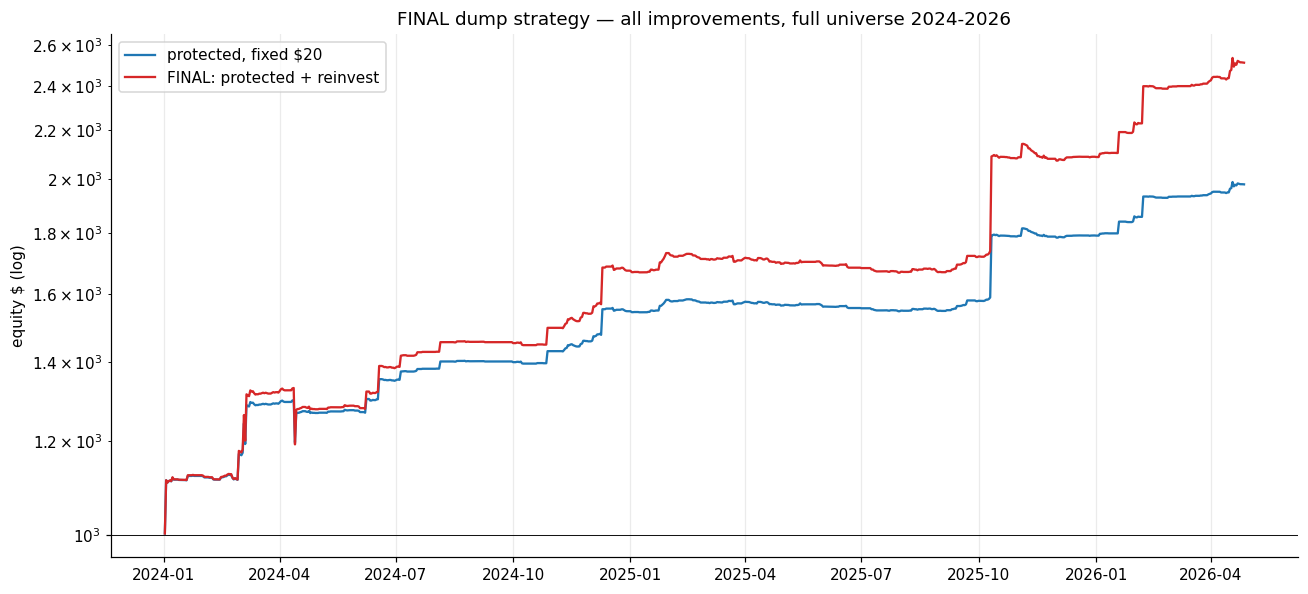

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5.5))
# final (compound) + v3 (fixed) for reference
res3=run(pnl_col="pnl_price",fill_label="price",use_filter=True,use_tail=True,compound=False)
for res,lab,col in [(res3,"protected, fixed $20","#1f77b4"),(resF,"FINAL: protected + reinvest","#d62728")]:
    s=pd.Series(res["eq_v"],index=pd.to_datetime(res["eq_t"])).sort_index()
    s=s[~s.index.duplicated(keep="last")].resample("1D").last().ffill()
    plt.plot(s.index,s.values,color=col,label=lab)
plt.yscale("log"); plt.axhline(1000,color="k",lw=.6)
plt.ylabel("equity $ (log)"); plt.title("FINAL dump strategy — all improvements, full universe 2024-2026")
plt.legend(); show("11_final")

## Что в финальной конфигурации
price-step fill + walk-forward классификатор-фильтр (pred>0) + catastrophe-стоп
−20% + kill-switch K=40 + реинвест 2%/капитала. Полная вселенная, 2024–2026.

**Как читать:** таблица прогрессии показывает вклад каждого улучшения (apples-to-apples
на фикс $20), последняя строка добавляет реинвест. Детальная таблица — полная
статистика финала (сделки, win, Sharpe/Sortino/Calmar, DD, комиссии).

**Честные оговорки (неизменны):** хвост вне выборки (системный каскад) не покрыт
данными — стоп/KS это страховка, не гарантия; стоп close-based; слиппедж на
микрокапах смоделирован грубо; live ещё не торговали.

## VERDICT (iter 11 — ФИНАЛ)

**Все улучшения вместе, полная вселенная 2024-2026, walk-forward, реинвест.**
Прогрессия (фикс $20): v0 time +81%/Sharpe2.05/DD−6.2% → v1 +price-step
+124%/2.03/−5.5% (Calmar 7.64) → v2 +классификатор(WF) +120%/2.10/−5.5% →
v3 +tail-лимиты +98%/1.88/−7.9% → **FINAL +реинвест +151%/CAGR48.8%/Sharpe1.91/
Sortino2.82/maxDD−10.4%/Calmar4.69**. WF OOS corr +0.227.

FINAL detail: 4286 сигналов → 2094 после фильтра+KS → 2015 взято; win 62.9%,
mean +2.64%, q10 −7.39%, worst −20.2% (стоп), комиссий $97, итог $2511.

**ЧЕСТНО: «всё вместе» ≠ лучшая in-sample кривая.** Лучший риск-скор у v1/v2
(Sharpe ~2.1, Calmar 7.6, DD −5.5%). Tail-лимиты и реинвест УХУДШАЮТ in-sample
(DD −5.5→−10.4%) — это плата: лимиты = страховка от несэмплированного каскада
(стоп режет убытки, что в выборке всегда отскакивали); реинвест = рост ценой
гладкости. Выбор конфига = выбор философии, не «макс всё»:
- гладкость/без хвостовой защиты → v1/v2 (DD −5.5%, CAGR ~41%);
- рост+страховка → FINAL (CAGR 48.8%, DD −10.4%).

**Оговорки:** системный каскад вне данных; стоп close-based; слиппедж грубо; live=0.
**Дальше:** объединение с pump (uncorrelated → ниже DD); порт в strategies/бот.